## Step 1: Data Loading
Load the dataset and inspect the first few records.

In [2]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Load dataset
df = pd.read_csv("../data/student_performance.csv")

# Display first 5 rows
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


**Observation**
- Dataset loaded successfully.
- The first five records help verify that the data has been imported correctly.

## Step 2: Dataset Overview
Check the dataset size, columns, and data types.

In [3]:
# Shape of the dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:\n")
print(df.columns.tolist())

# Data types
print("\nData Types:\n")
df.dtypes

Shape: (6607, 20)

Columns:

['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

Data Types:



Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
Exam_Score                    int64
dtype: object

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [5]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.029060,1.468120,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.493719,1.230570,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.967610,1.031231,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.235659,3.890456,55.0,65.0,67.0,69.0,101.0


## Step 6: Handle Missing Values
Fill missing values in categorical columns using the mode.

In [7]:
# Fill missing values with mode

categorical_cols = [
    "Teacher_Quality",
    "Parental_Education_Level",
    "Distance_from_Home"
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify missing values
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

**Observation**
- Missing values were filled using the mode.
- The dataset now contains no missing values.

## Step 8: Exam Score Distribution
Visualize the distribution of the target variable.

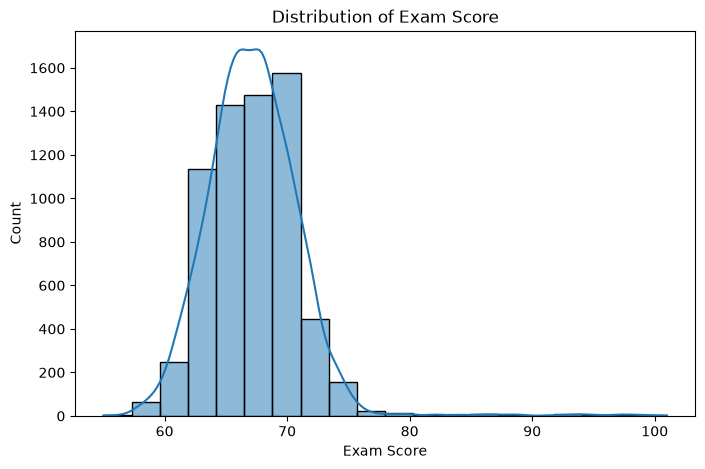

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Exam_Score"], bins=20, kde=True)

plt.title("Distribution of Exam Score")
plt.xlabel("Exam Score")
plt.ylabel("Count")

plt.show()

## Step 9: Correlation Analysis
Check the relationship between numerical features.

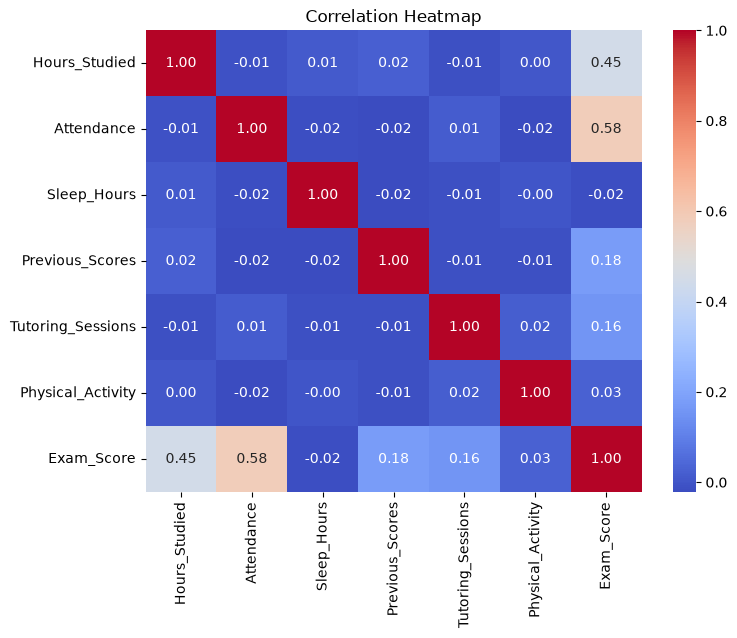

In [9]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

## Step 10: Hours Studied vs Exam Score
Analyze the relationship between study hours and exam score.

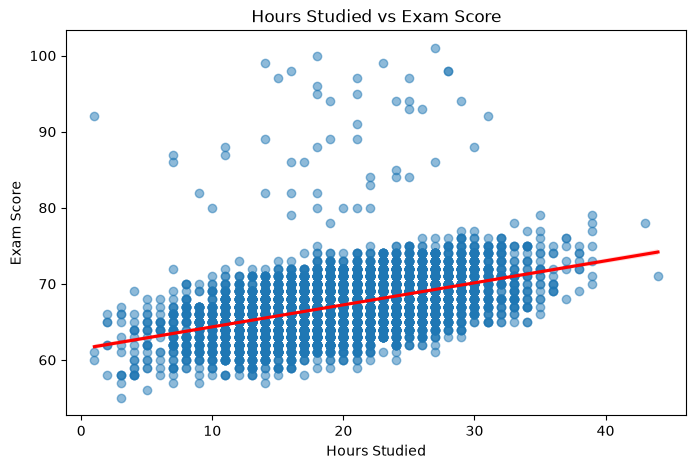

In [10]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Hours_Studied",
    y="Exam_Score",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.show()

**Observation**
- Exam scores generally increase with study hours.
- The regression line indicates a positive relationship between the two variables.

## Step 11: Outlier Detection
Visualize outliers in numerical features.

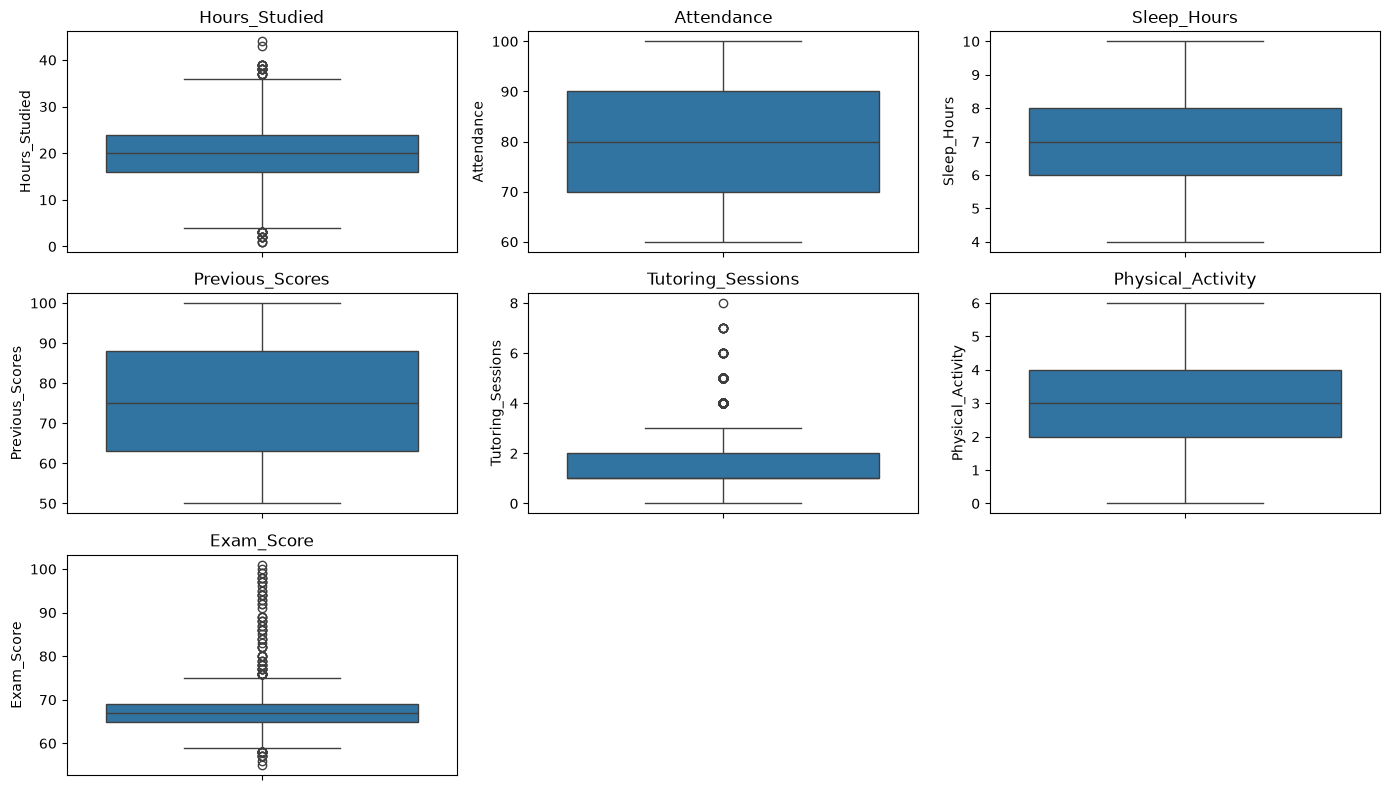

In [11]:
# Select numerical columns
numerical_cols = df.select_dtypes(include="number").columns

plt.figure(figsize=(14, 8))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**Observation**
- Hours_Studied, Tutoring_Sessions, and Exam_Score contain a few outliers.
- Most numerical features have a reasonable spread without extreme variation.

## Step 14: Encode Categorical Features
Convert categorical variables into numerical values.

In [12]:
categorical_cols = df.select_dtypes(include="object").columns

print(categorical_cols.tolist())

['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


C:\Users\Hp\AppData\Local\Temp\ipykernel_3884\2801479450.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


## Step 14.1: Inspect Categorical Values
Check unique values before encoding.

In [13]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


Parental_Involvement
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

Access_to_Resources
<StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str

Extracurricular_Activities
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Motivation_Level
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

Internet_Access
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Family_Income
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

Teacher_Quality
<StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str

School_Type
<StringArray>
['Public', 'Private']
Length: 2, dtype: str

Peer_Influence
<StringArray>
['Positive', 'Negative', 'Neutral']
Length: 3, dtype: str

Learning_Disabilities
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Parental_Education_Level
<StringArray>
['High School', 'College', 'Postgraduate']
Length: 3, dtype: str

Distance_from_Home
<StringArray>
['Near', 'Moderate', 'Far']
Length: 3, dtype: str

Gender
<StringArray>
['Male', 

## Step 15: Feature Encoding
Encode categorical features using appropriate techniques.

In [14]:
df_encoded = df.copy()

In [15]:
# Ordinal mappings
level_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

distance_map = {
    "Near": 0,
    "Moderate": 1,
    "Far": 2
}

education_map = {
    "High School": 0,
    "College": 1,
    "Postgraduate": 2
}

ordinal_cols = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Motivation_Level",
    "Family_Income",
    "Teacher_Quality"
]

for col in ordinal_cols:
    df_encoded[col] = df_encoded[col].map(level_map)

df_encoded["Distance_from_Home"] = df_encoded["Distance_from_Home"].map(distance_map)

df_encoded["Parental_Education_Level"] = df_encoded["Parental_Education_Level"].map(education_map)

peer_map = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

df_encoded["Peer_Influence"] = df["Peer_Influence"].map(peer_map)

df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   int64
 3   Access_to_Resources         6607 non-null   int64
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   int64
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   int64
 11  Teacher_Quality             6607 non-null   int64
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   int64
 14  Physical_Activity  

In [16]:
binary_map = {
    "Yes": 1,
    "No": 0,
    "Male": 1,
    "Female": 0
}

binary_cols = [
    "Extracurricular_Activities",
    "Internet_Access",
    "Learning_Disabilities",
    "Gender"
]

for col in binary_cols:
    df_encoded[col] = df_encoded[col].map(binary_map)

In [17]:
df_encoded = pd.get_dummies(
    df_encoded,
    columns=["School_Type"],
    drop_first=True,
    dtype=int
)

In [29]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   int64
 3   Access_to_Resources         6607 non-null   int64
 4   Extracurricular_Activities  6607 non-null   int64
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   int64
 8   Internet_Access             6607 non-null   int64
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   int64
 11  Teacher_Quality             6607 non-null   int64
 12  Peer_Influence              6607 non-null   int64
 13  Physical_Activity           6607 non-null   int64
 14  Learning_Disabiliti


**Observation**
- All categorical features have been converted into numerical format.
- The dataset is now ready for model training."

In [20]:
peer_map = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

df_encoded["Peer_Influence"] = df["Peer_Influence"].map(peer_map)

## Step 15: Feature and Target Selection
Separate input features and target variable.

In [21]:
# Features
X = df_encoded.drop("Exam_Score", axis=1)

# Target
y = df_encoded["Exam_Score"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (6607, 19)
Target Shape  : (6607,)


**Observation**
- Features and target variable have been separated successfully.

## Step 16: Train-Test Split
Split the dataset into training and testing sets.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (5285, 19)
Testing Set  : (1322, 19)


**Observation**
- The dataset is split into 80% training and 20% testing data.

## Step 17: Feature Scaling
Standardize numerical features.

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


**Observation**
- Features have been standardized for model training.

## Step 18: Linear Regression
Train the Linear Regression model.

In [24]:
from sklearn.linear_model import LinearRegression

# Train model
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


**Observation**
- Linear Regression model has been trained successfully.

## Step 19: Model Prediction
Predict exam scores using the trained model.

In [25]:
# Prediction
y_pred_lr = lr_model.predict(X_test_scaled)

**Observation**
- Predictions have been generated for the test dataset.

## Step 20: Model Evaluation
Evaluate the Linear Regression model.

In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.44
RMSE : 1.80
R²   : 0.7709


**Observation**
- Linear Regression achieved an R² score of 0.6888.
- The model provides a good baseline with low prediction error.

## Step 21: Actual vs Predicted Scores
Compare actual and predicted exam scores.

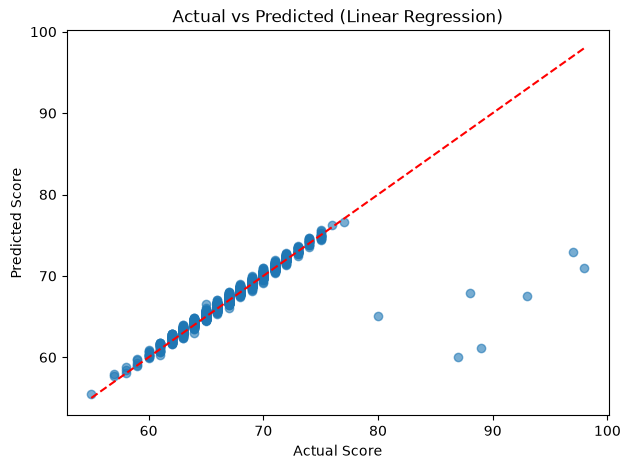

In [27]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred_lr, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted (Linear Regression)")

plt.show()

**Observation**
- Points closer to the diagonal line indicate better predictions.

## Step 22: Random Forest Regressor
Train the Random Forest Regressor.

In [28]:
rf_reg.fit(X_train, y_train)

y_pred_rf = rf_reg.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R²   : {r2_rf:.4f}")

print("Train R² :", rf_reg.score(X_train, y_train))
print("Test R²  :", rf_reg.score(X_test, y_test))

NameError: name 'rf_reg' is not defined

## Step 23: Model Prediction
Predict exam scores using Random Forest.

In [ ]:
y_pred_rf = rf_reg.predict(X_test)

## Step 24: Model Evaluation
Evaluate the Random Forest Regressor.

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R²   : {r2_rf:.4f}")

MAE  : 1.09
RMSE : 2.12
R²   : 0.6813


In [ ]:
rf_reg

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [ ]:
print(X_train.shape)
print(X_test.shape)

(5285, 19)
(1322, 19)


In [ ]:
print("Train R² :", rf_reg.score(X_train, y_train))
print("Test R²  :", rf_reg.score(X_test, y_test))

Train R² : 0.778795817962384
Test R²  : 0.6813212910819365
